# Data Exploration

Melakukan Penginstallan streamlit untuk menggunakan import streamlit di google colab

In [9]:
!pip install plotly
!pip install --upgrade nbformat
!pip install streamlit
!pip install statsmodels

Melakukan import pada library yang dibutuhkan

In [10]:
import pandas as pd
import streamlit as st
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error, r2_score, mean_absolute_error
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import joblib
import io
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_predict
from scipy import stats
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import f_oneway, chi2_contingency

Membaca File dan menampilkan beberapa baris awal

In [11]:
df = pd.read_csv('student_habits_performance.csv')
df.head(10)

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4
5,S1005,24,Male,7.2,1.3,0.0,No,82.9,7.4,Fair,1,Master,Average,4,No,100.0
6,S1006,21,Female,5.6,1.5,1.4,Yes,85.8,6.5,Good,2,Master,Poor,4,No,89.8
7,S1007,21,Female,4.3,1.0,2.0,Yes,77.7,4.6,Fair,0,Bachelor,Average,8,No,72.6
8,S1008,23,Female,4.4,2.2,1.7,No,100.0,7.1,Good,3,Bachelor,Good,1,No,78.9
9,S1009,18,Female,4.8,3.1,1.3,No,95.4,7.5,Good,5,Bachelor,Good,10,Yes,100.0


# Data Understanding


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Menampilkan Ringkasan statistik dari data

In [13]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


Cek Info dalam data

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

Cek Duplikasi

In [15]:
df.duplicated().sum()

np.int64(0)

Cek Data Null

In [16]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


Mengisi data null dengan modus

In [17]:
df["parental_education_level"] = df["parental_education_level"].fillna(df["parental_education_level"].mode()[0])

df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


mengecek kembali nilai null

In [18]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0
diet_quality,0


melakukan drop kolom yang tidak relevan

In [19]:
df.drop(columns=["student_id"],inplace=True)
df.drop(columns=["gender"],inplace=True)

melakukan one-hot encoding

In [20]:
df_encoded = pd.get_dummies(df, columns= ['extracurricular_participation', 'part_time_job'])
df_encoded.head()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,exam_score,extracurricular_participation_No,extracurricular_participation_Yes,part_time_job_No,part_time_job_Yes
0,23,0.0,1.2,1.1,85.0,8.0,Fair,6,Master,Average,8,56.2,False,True,True,False
1,20,6.9,2.8,2.3,97.3,4.6,Good,6,High School,Average,8,100.0,True,False,True,False
2,21,1.4,3.1,1.3,94.8,8.0,Poor,1,High School,Poor,1,34.3,True,False,True,False
3,23,1.0,3.9,1.0,71.0,9.2,Poor,4,Master,Good,1,26.8,False,True,True,False
4,19,5.0,4.4,0.5,90.9,4.9,Fair,3,Master,Good,1,66.4,True,False,True,False


mengubah data kategorikal menjadi data numerik

In [21]:
label_columns =  ['part_time_job', 'diet_quality', 'parental_education_level',
                    'internet_quality', 'extracurricular_participation']
le = LabelEncoder()
for col in label_columns:
    if col in df_encoded.columns:
        df_encoded[col] = le.fit_transform(df_encoded[col])


melihat korelasi dengan exam score dan memvisualisasikan dengan heatmap

In [22]:
categorical_cols = ['part_time_job', 'diet_quality',
                          'parental_education_level', 'internet_quality',
                          'extracurricular_participation']
for col in categorical_cols:
  value_counts = df[col].value_counts()
  fig = px.pie(values=value_counts.values,
  names=value_counts.index,
   title=f'Distribusi {col.replace("_", " ").title()}')
st.plotly_chart(fig)

2026-05-26 23:33:11.234 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 23:33:11.235 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 23:33:11.236 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 23:33:11.444 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-26 23:33:11.445 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-26 23:33:11.446 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

menganalisis dan memvisualisasikan hubungan

Membuat Heatmap Korelasi...


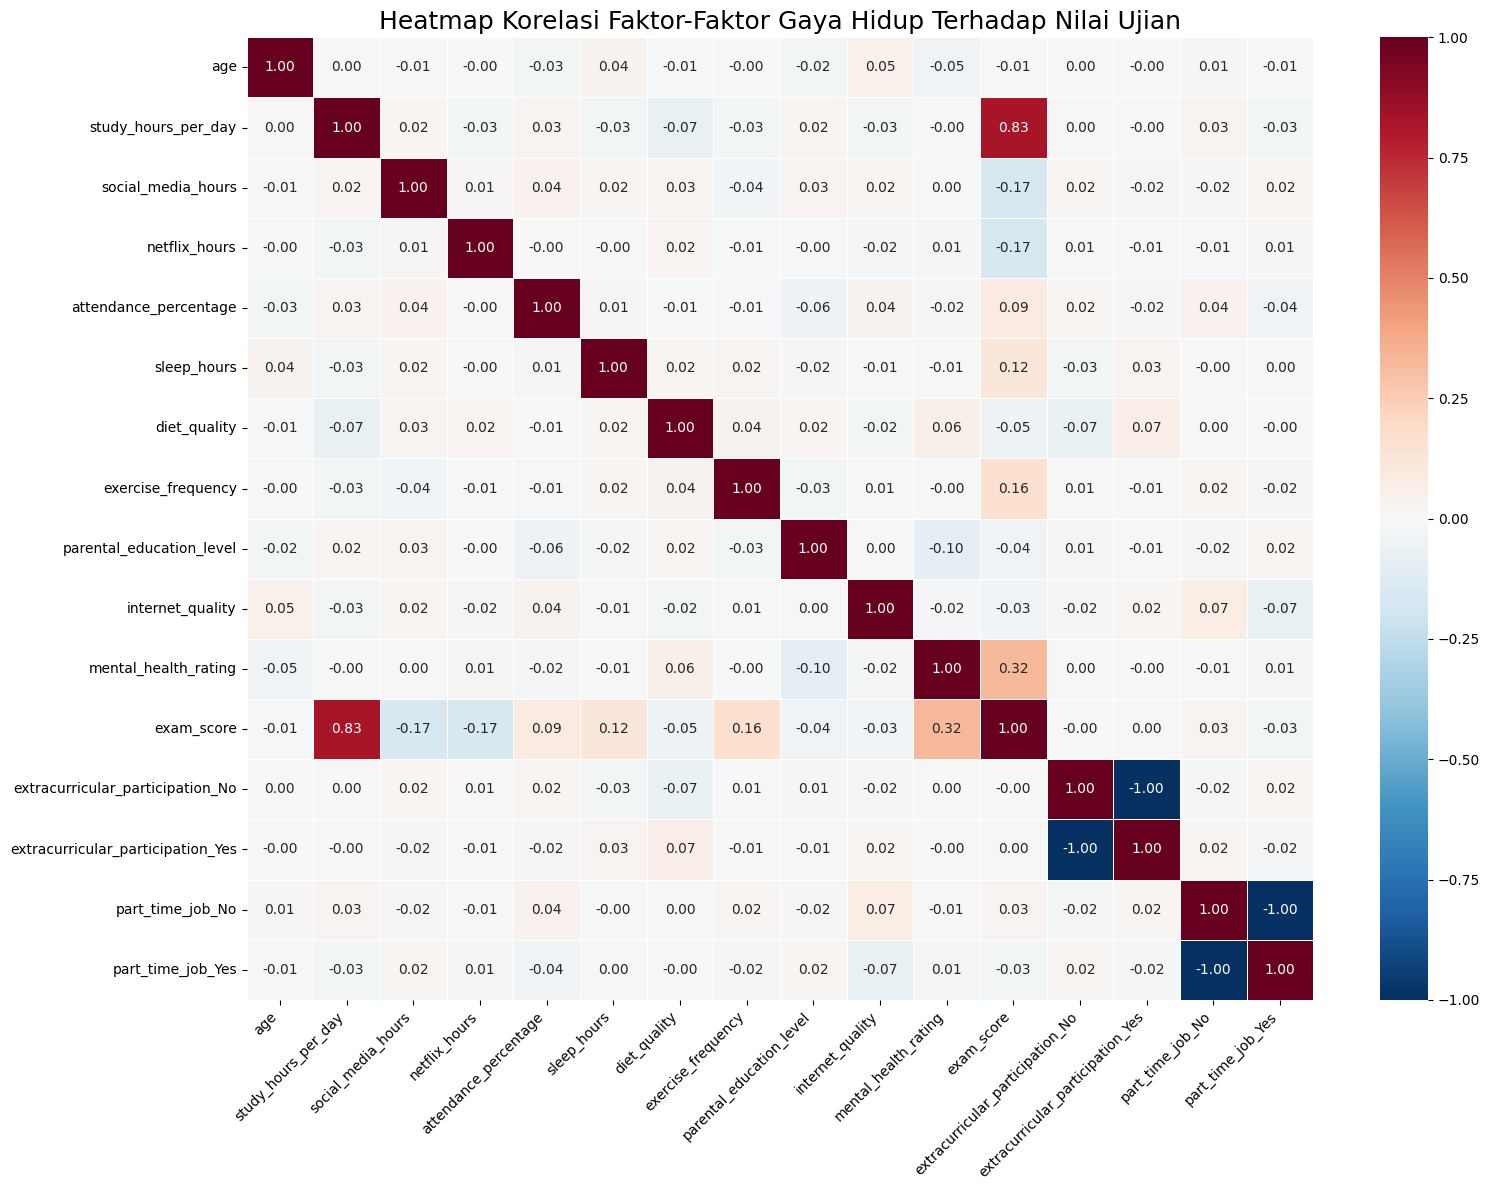



Membuat Visualisasi Fokus pada 'exam_score'...


/tmp/ipykernel_29775/1739890958.py:27: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




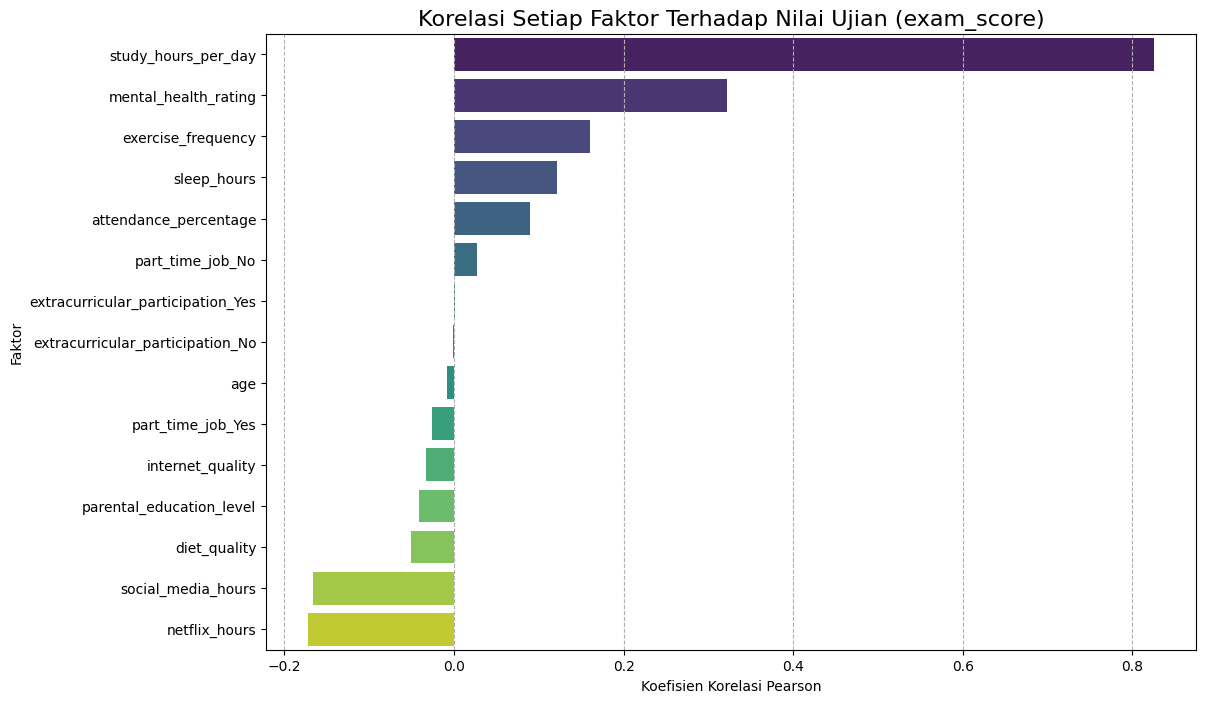

In [23]:
df = df_encoded

df['exam_score'] = df['exam_score'].clip(0, 100)

correlation_matrix = df.corr()

print("Membuat Heatmap Korelasi...")
plt.figure(figsize=(16, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='RdBu_r',
    fmt='.2f',
    linewidths=.5
)
plt.title('Heatmap Korelasi Faktor-Faktor Gaya Hidup Terhadap Nilai Ujian', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n" + "="*50 + "\n")
print("Membuat Visualisasi Fokus pada 'exam_score'...")
exam_score_corr = correlation_matrix['exam_score'].drop('exam_score').sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=exam_score_corr.values, y=exam_score_corr.index, palette='viridis')
plt.title("Korelasi Setiap Faktor Terhadap Nilai Ujian (exam_score)", fontsize=16)
plt.xlabel("Koefisien Korelasi Pearson")
plt.ylabel("Faktor")
plt.grid(axis='x', linestyle='--')
plt.show()

visualisasi data outlier dengan boxplot

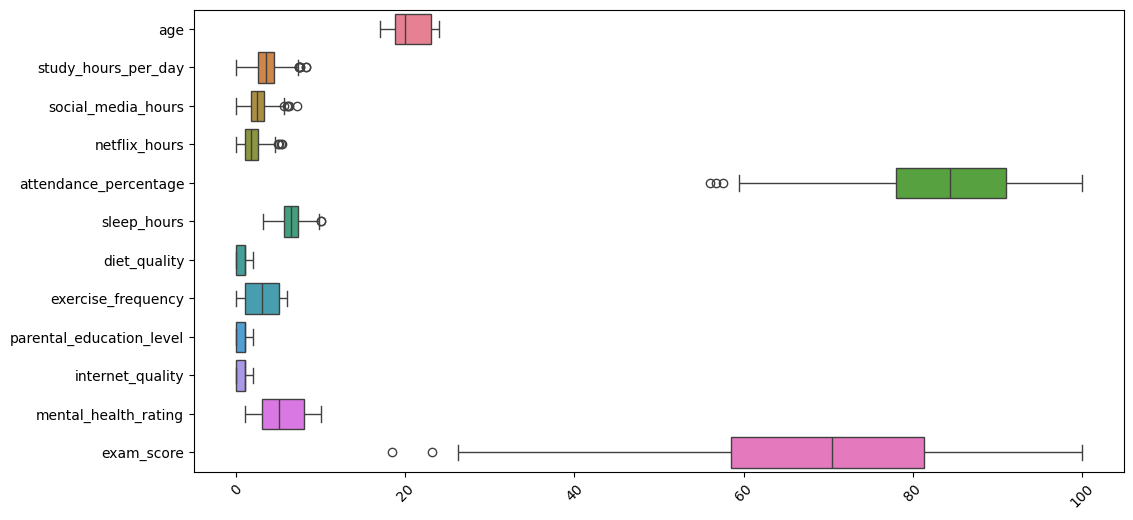

In [24]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include=['number']), orient="h")
plt.xticks(rotation=45)
plt.show()


menggunakan standardscaler

In [25]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
scaled_data = pd.DataFrame(scaled_data, columns=df.columns)
scaled_data.head()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,exam_score,extracurricular_participation_No,extracurricular_participation_Yes,part_time_job_No,part_time_job_Yes
0,1.084551,-2.418068,-1.114064,-0.669750,0.092426,1.248120,-1.000902,1.461166,1.701303,-1.089750,0.900186,-0.793922,-1.464464,1.464464,0.523341,-0.523341
1,-0.215870,2.281707,0.251315,0.446965,1.401696,-1.525661,0.337202,1.461166,0.263177,-1.089750,0.900186,1.800846,0.682844,-0.682844,0.523341,-0.523341
2,0.217604,-1.464491,0.507324,-0.483631,1.135584,1.248120,1.675307,-1.008689,0.263177,1.737098,-1.559339,-2.091307,0.682844,-0.682844,0.523341,-0.523341
3,1.084551,-1.736942,1.190013,-0.762810,-1.397800,2.227102,1.675307,0.473224,1.701303,0.323674,-1.559339,-2.535616,-1.464464,1.464464,0.523341,-0.523341
4,-0.649344,0.987566,1.616694,-1.228108,0.720450,-1.280916,-1.000902,-0.020747,1.701303,0.323674,-1.559339,-0.189661,0.682844,-0.682844,0.523341,-0.523341


Analisis Komponen Utama (PCA)

In [26]:
numeric_features = [
    'age',
    'study_hours_per_day',
    'social_media_hours',
    'netflix_hours',
    'attendance_percentage',
    'sleep_hours',
    'exercise_frequency',
    'mental_health_rating'
]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numeric_features])

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

exp_var_ratio = pca.explained_variance_ratio_
cum_exp_var_ratio = np.cumsum(exp_var_ratio)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        'Rasio Varians Individual per Komponen',
        'Rasio Varians Kumulatif'
    )
)

fig.add_trace(
    go.Bar(
        x=[f'PC{i+1}' for i in range(len(exp_var_ratio))],
        y=exp_var_ratio,
        name='Individual Variance',
        marker_color='royalblue'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=[f'PC{i+1}' for i in range(len(cum_exp_var_ratio))],
        y=cum_exp_var_ratio,
        mode='lines+markers',
        name='Cumulative Variance',
        marker_color='firebrick'
    ),
    row=1, col=2
)

fig.update_layout(
    title_text='Analisis Explained Variance PCA',
    height=450,
    width=900,
    showlegend=False,
    yaxis1_title='Rasio Varians',
    yaxis2_title='Rasio Varians Kumulatif',
    xaxis1_title='Komponen Utama',
    xaxis2_title='Komponen Utama'
)
fig.show()

print("="*50)
print("Detail Explained Variance per Komponen Utama (PC)")
print("="*50)
for i, var in enumerate(exp_var_ratio):
    print(f"PC{i+1}: {var:.4f} (Total Kumulatif: {cum_exp_var_ratio[i]:.4f})")
print("="*50)


Detail Explained Variance per Komponen Utama (PC)
PC1: 0.1358 (Total Kumulatif: 0.1358)
PC2: 0.1327 (Total Kumulatif: 0.2685)
PC3: 0.1296 (Total Kumulatif: 0.3981)
PC4: 0.1266 (Total Kumulatif: 0.5247)
PC5: 0.1235 (Total Kumulatif: 0.6482)
PC6: 0.1194 (Total Kumulatif: 0.7676)
PC7: 0.1177 (Total Kumulatif: 0.8853)
PC8: 0.1147 (Total Kumulatif: 1.0000)


PCA

In [27]:
data_pca = ['age','study_hours_per_day','social_media_hours','netflix_hours','attendance_percentage','sleep_hours','exercise_frequency','mental_health_rating']

data_value = df[data_pca]

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_value)



pca = PCA(n_components=2)
data_reduced = pca.fit_transform(data_scaled)
data_pca = pd.DataFrame(data_reduced, columns=['PC1', 'PC2'])

print("data sebelum pca")
print(data_scaled[:5])
print("data seletah pca")
print(data_pca[:5])

data sebelum pca
[[ 1.08455114 -2.41806844 -1.11406369 -0.66975012  0.09242597  1.24812012
   1.46116644  0.90018637]
 [-0.21586989  2.28170684  0.25131502  0.44696538  1.40169634 -1.52566144
   1.46116644  0.90018637]
 [ 0.21760379 -1.46449085  0.50732352 -0.48363087  1.13558447  1.24812012
  -1.00868893 -1.55933923]
 [ 1.08455114 -1.73694159  1.19001288 -0.76280974 -1.39780046  2.22710185
   0.47322429 -1.55933923]
 [-0.64934357  0.98756582  1.61669372 -1.22810787  0.72044997 -1.28091601
  -0.02074679 -1.55933923]]
data seletah pca
        PC1       PC2
0 -2.757665  0.386531
1  1.544364 -1.010921
2  0.250011  1.911808
3 -1.744650  2.504863
4  2.090331  0.494311


# Data Modelling


mengimpor dari library Scikit-learn

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

mencari optimal k menggunakan elbow method dan divisualisasikan

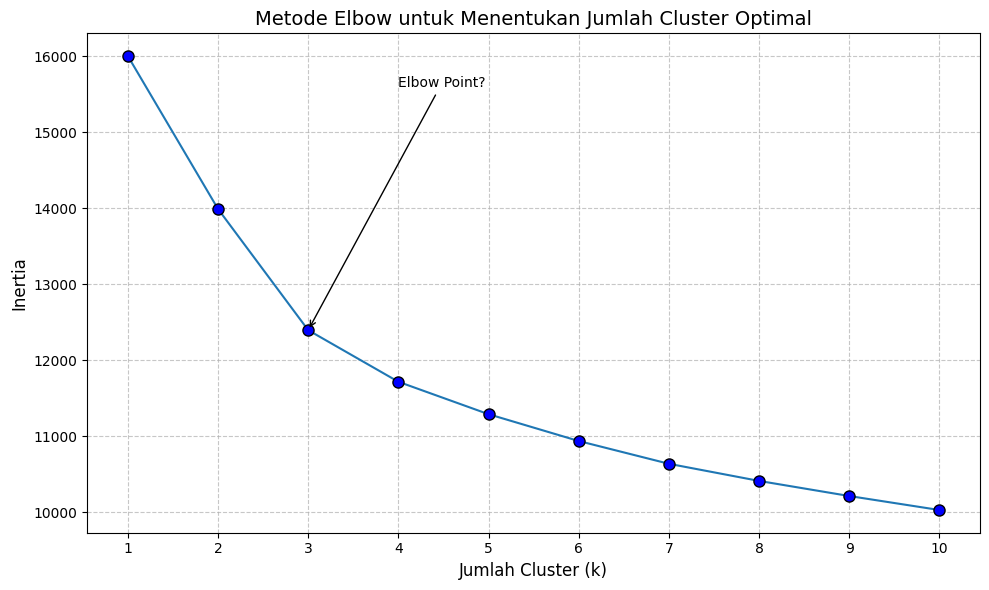

In [29]:
inertia = []
k_range = range(1,11)
for k in k_range:
  kmeans = KMeans( n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(scaled_data)
  inertia.append(kmeans.inertia_)

#visualisasi Elbow Method
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'o-', markersize=8, markerfacecolor='blue', markeredgecolor='black')
plt.xlabel('Jumlah Cluster (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Metode Elbow untuk Menentukan Jumlah Cluster Optimal', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(k_range)

plt.annotate('Elbow Point?',
            xy=(3, inertia[2]),
            xytext=(4, inertia[2]+inertia[0]*0.2),
            arrowprops=dict(arrowstyle='->'))

plt.tight_layout()
plt.show()

mengubah data kategorikal (berbasis teks) menjadi data numerik (berbasis angka)

In [30]:
categorical_cols = ['diet_quality', 'parental_education_level',
                    'internet_quality']
label_encoders = {col: LabelEncoder() for col in categorical_cols}

for col in categorical_cols:
    df[col] = label_encoders[col].fit_transform(df[col])

persiapan data

In [31]:
X = df.drop(columns=['exam_score'])
y = df['exam_score']
imputer = SimpleImputer(strategy='most_frequent')
X_imputed = imputer.fit_transform(X)

Standardisasi Fitur

In [32]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

mengelompokkan data Anda ke dalam 2 cluster

In [33]:
optimal_k = 2

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

df['cluster'] = cluster_labels

silhouette_avg = silhouette_score(X_scaled, cluster_labels)
print(f"Silhouette Score untuk k={optimal_k}: {silhouette_avg:.4f}")

Silhouette Score untuk k=2: 0.1793


menganalisis dan memahami karakteristik dari setiap cluster

In [34]:
kolom_untuk_clustering = [
    'age',
    'study_hours_per_day',
    'mental_health_rating',
    'part_time_job_Yes'
]
kolom_analisis = kolom_untuk_clustering + ['exam_score']
cluster_analysis = df[kolom_analisis + ['cluster']].groupby('cluster').mean().round(2)
print(cluster_analysis)

           age  study_hours_per_day  mental_health_rating  part_time_job_Yes  \
cluster                                                                        
0        20.45                 3.47                  5.51                1.0   
1        20.51                 3.57                  5.42                0.0   

         exam_score  
cluster              
0             68.74  
1             69.84  


mengubah masalah dari prediksi nilai (regresi) menjadi masalah klasifikasi biner (dua kelas)

In [35]:
df['passed'] = (df['exam_score'] >= 60).astype(int)
y_binary = df['passed']

membagi dataset menjadi dua bagian: satu untuk melatih model, dan satu lagi untuk mengujinya.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_binary, test_size=0.2, random_state=42)

inisialisasi dan pelatihan model

In [37]:
model = GaussianNB()
model.fit(X_train, y_train)



GaussianNB()

# Model Evaluation

membuat prediksi menggunakan model yang sudah dilatih

In [38]:
y_pred = model.predict(X_test)


menghitung dan menampilkan jumlah data untuk setiap kelas (kategori) dalam variabel target Anda

In [39]:
y.value_counts()
# 0 (Rendah): 900
# 1 (Tinggi): 100

,count
exam_score,
100.0,48
80.9,7
65.6,7
74.0,7
70.7,7
...,...
69.8,1
46.8,1
45.4,1


menghitung dan menampilkan skor akurasi

In [40]:
akurasi = accuracy_score(y_test, y_pred)
print("Akurasi Model:", akurasi)

Akurasi Model: 0.935


membuat dan menampilkan "Confusion Matrix"

In [41]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 42   9]
 [  4 145]]


In [42]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.82      0.87        51
           1       0.94      0.97      0.96       149

    accuracy                           0.94       200
   macro avg       0.93      0.90      0.91       200
weighted avg       0.93      0.94      0.93       200



In [43]:
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAkurasi Model Naive Bayes: {accuracy:.2f}")



Akurasi Model Naive Bayes: 0.94


Import ROC dan AUC

In [44]:
from sklearn.metrics import roc_curve, roc_auc_score, auc
import matplotlib.pyplot as plt


mendapatkan probabilitas atau "tingkat kepercayaan" model

In [45]:
y_prob = model.predict_proba(X_test)

menghitung nilai-nilai yang dibutuhkan untuk membuat Kurva ROC

In [46]:
fpr, tpr, thresholds = roc_curve(y_test, 1 - y_prob[:, 0])

print("FPR:", fpr)
print("TPR:", tpr)
print("Thresholds:", thresholds)

FPR: [0.         0.         0.         0.03921569 0.03921569 0.05882353
 0.05882353 0.07843137 0.07843137 0.09803922 0.09803922 0.11764706
 0.11764706 0.1372549  0.1372549  0.17647059 0.17647059 0.23529412
 0.23529412 0.29411765 0.29411765 0.41176471 0.41176471 1.        ]
TPR: [0.         0.00671141 0.55704698 0.55704698 0.79194631 0.79194631
 0.8590604  0.8590604  0.87919463 0.87919463 0.93959732 0.93959732
 0.95302013 0.95302013 0.96644295 0.96644295 0.97315436 0.97315436
 0.98657718 0.98657718 0.99328859 0.99328859 1.         1.        ]
Thresholds: [       inf 0.99985216 0.92311292 0.9198401  0.77366716 0.77364933
 0.69547594 0.68105719 0.66440569 0.64475419 0.57086458 0.55019656
 0.53643961 0.52036682 0.50882934 0.50402145 0.50108279 0.44640952
 0.43536279 0.36120796 0.32530197 0.28137939 0.28058752 0.02893781]


menghitung dan menampilkan skor AUC

In [47]:
roc_auc = auc(fpr, tpr)

print(f"AUC: {roc_auc:.2f}")

AUC: 0.97


membuat dan menampilkan grafik Kurva ROC

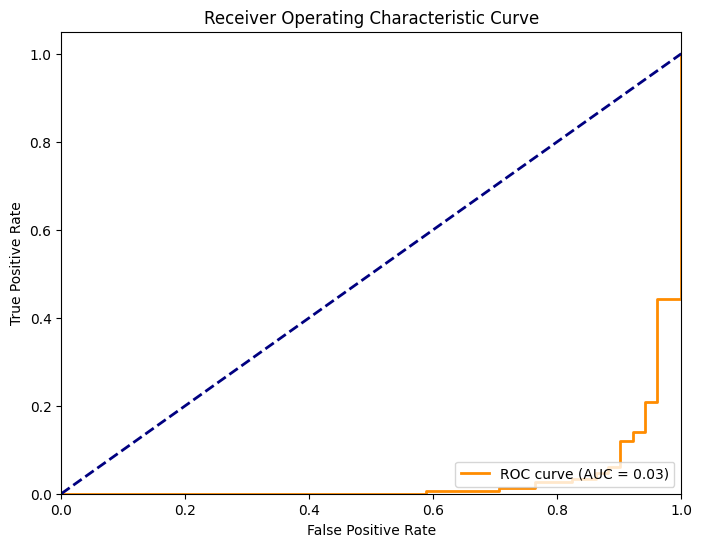

In [48]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob[:, 0])

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc='lower right')

plt.show()

mengevaluasi tipe model

In [49]:
model = GaussianNB()
model.fit(X_train, y_train)

roc_auc_scores = cross_val_score(model, X, y_binary, cv=5, scoring='roc_auc')

menampilkan hasil dari evaluasi model

In [50]:
print("ROC AUC per fold:", roc_auc_scores)
print(f"Rata-rata ROC AUC: {roc_auc_scores.mean():.4f}")

ROC AUC per fold: [0.95672123 0.96279762 0.95969742 0.9453125  0.95907738]
Rata-rata ROC AUC: 0.9567


menghitung akurasi model

In [51]:
y_pred = cross_val_predict(model, X, y_binary, cv=5)

accuracy = accuracy_score(y_binary, y_pred)

print(f"Akurasi model: {accuracy:.4f}")

Akurasi model: 0.8950


menampilkan Confusion Matrix

In [52]:
cm = confusion_matrix(y_binary, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[210  70]
 [ 35 685]]


laporan detail tentang performa model klasifikasi

In [53]:
report = classification_report(y_binary, y_pred, target_names=["Lulus", "Tidak Lulus"])
print(report)

              precision    recall  f1-score   support

       Lulus       0.86      0.75      0.80       280
 Tidak Lulus       0.91      0.95      0.93       720

    accuracy                           0.90      1000
   macro avg       0.88      0.85      0.86      1000
weighted avg       0.89      0.90      0.89      1000



Evaluasi  5-Fold Cross-Validation.

In [54]:
roc_auc_scores = cross_val_score(model, X, y_binary, cv=5, scoring='roc_auc')

print("ROC AUC per fold:", roc_auc_scores)

print(f"Rata-rata ROC AUC: {roc_auc_scores.mean():.4f}")

ROC AUC per fold: [0.95672123 0.96279762 0.95969742 0.9453125  0.95907738]
Rata-rata ROC AUC: 0.9567


# Deployment

Pembuatan file app.py

In [55]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import joblib
import io
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from scipy import stats
from scipy.stats import f_oneway, chi2_contingency
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

st.set_page_config(page_title="Dasbor Analisis Kinerja Siswa", layout="wide")

st.title("Dasbor Analisis Kinerja Siswa")
st.markdown("""
Dasbor ini menganalisis kinerja siswa berdasarkan berbagai faktor termasuk kebiasaan belajar,
gaya hidup, dan karakteristik pribadi.
""")

@st.cache_data
def load_data():
    df = pd.read_csv('student_habits_performance.csv')
    return df

try:
    df = load_data()

    st.sidebar.title("Navigasi")
    page = st.sidebar.radio("Pergi ke", [
        "1. Pemahaman Data",
        "2. Pra-pemrosesan Data",
        "3. Analisis Eksplorasi",
        "4. Rekayasa Fitur",
        "5. Analisis Klaster",
        "6. Pemodelan & Evaluasi",
        "7. Prediksi"
    ])

    if page == "1. Pemahaman Data":
        st.header("Pemahaman Data")
        st.write("Bentuk dataset:", df.shape)

        st.subheader("Contoh Data")
        st.dataframe(df.head())

        st.subheader("Informasi Data")
        buffer = io.StringIO()
        df.info(buf=buffer)
        st.text(buffer.getvalue())

        st.subheader("Statistik Data Numerik")
        st.write(df.describe())

        categorical_cols = ['part_time_job', 'diet_quality',
                          'parental_education_level', 'internet_quality',
                          'extracurricular_participation']

        for col in categorical_cols:
            value_counts = df[col].value_counts()
            fig = px.pie(values=value_counts.values,
                        names=value_counts.index,
                        title=f'Distribusi {col.replace("_", " ").title()}')
            st.plotly_chart(fig)

        st.subheader("Analisis Nilai Hilang")
        missing_values = df.isnull().sum()
        if missing_values.sum() > 0:
            st.write("Jumlah Nilai Hilang:")
            st.write(missing_values[missing_values > 0])

            fig = plt.figure(figsize=(10, 6))
            sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
            plt.title('Peta Panah Nilai Hilang')
            st.pyplot(fig)
        else:
            st.success("Tidak ditemukan nilai hilang dalam dataset!")

    elif page == "2. Pra-pemrosesan Data":
        st.header("Pra-pemrosesan Data")

        st.subheader("Ringkasan Data Asli")
        st.write("Bentuk:", df.shape)

        st.subheader("1. Penanganan Nilai Hilang")
        missing_values = df.isnull().sum()
        if missing_values.sum() > 0:
            st.write("Nilai hilang ditemukan:")
            st.write(missing_values[missing_values > 0])
        else:
            st.success("Tidak ada nilai hilang yang perlu ditangani!")

        st.subheader("2. Deteksi Pencilan")
        numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

        selected_col = st.selectbox("Pilih kolom untuk analisis pencilan:", numeric_cols)

        fig = go.Figure()
        fig.add_trace(go.Box(y=df[selected_col], name=selected_col))
        fig.update_layout(title=f'Box Plot {selected_col}')
        st.plotly_chart(fig)

        Q1 = df[selected_col].quantile(0.25)
        Q3 = df[selected_col].quantile(0.75)
        IQR = Q3 - Q1
        outliers = df[(df[selected_col] < (Q1 - 1.5 * IQR)) | (df[selected_col] > (Q3 + 1.5 * IQR))][selected_col]
        st.write(f"Jumlah pencilan terdeteksi: {len(outliers)}")

        st.subheader("3. Pratinjau Skala Fitur")
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(df[numeric_cols])
        scaled_df = pd.DataFrame(scaled_data, columns=numeric_cols)

        col1, col2 = st.columns(2)
        with col1:
            st.write("Statistik Data Asli:")
            st.write(df[numeric_cols].describe())
        with col2:
            st.write("Statistik Data Terskala:")
            st.write(scaled_df.describe())

    elif page == "3. Analisis Eksplorasi":
        st.header("Analisis Data Eksplorasi")

        tab1, tab2, tab3 = st.tabs(["Analisis Univariate", "Analisis Bivariate", "Analisis Multivariate"])

        with tab1:
            st.subheader("Analisis Univariate")

            st.write("### Variabel Numerik")
            numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
            selected_num = st.selectbox("Pilih variabel numerik:", numeric_cols)

            fig = make_subplots(rows=2, cols=1,
                              subplot_titles=('Plot Distribusi', 'Box Plot'))

            fig.add_trace(go.Histogram(x=df[selected_num], name="Distribusi"),
                         row=1, col=1)
            fig.add_trace(go.Box(x=df[selected_num], name="Box Plot"),
                         row=2, col=1)

            fig.update_layout(height=600, title_text=f"Analisis {selected_num}")
            st.plotly_chart(fig)

            st.write("### Variabel Kategorikal")
            categorical_cols = ['part_time_job', 'diet_quality',
                              'parental_education_level', 'internet_quality',
                              'extracurricular_participation']

            selected_cat = st.selectbox("Pilih variabel kategorikal:", categorical_cols)

            value_counts = df[selected_cat].value_counts()
            percentages = (value_counts / len(df) * 100).round(1)

            fig = px.bar(x=value_counts.index, y=value_counts.values,
                        text=[f'{p}%' for p in percentages],
                        title=f'Distribusi {selected_cat}')
            fig.update_traces(textposition='outside')
            st.plotly_chart(fig)

        with tab2:
            st.subheader("Analisis Bivariate")

            analysis_type = st.radio("Pilih Jenis Analisis:",
                                   ["Numerik vs Numerik",
                                    "Numerik vs Kategorikal",
                                    "Kategorikal vs Kategorikal"])

            if analysis_type == "Numerik vs Numerik":
                x_num = st.selectbox("Pilih variabel X:", numeric_cols, key='x_num')
                y_num = st.selectbox("Pilih variabel Y:", numeric_cols, key='y_num')

                fig = px.scatter(df, x=x_num, y=y_num,
                               trendline="ols",
                               title=f'{x_num} vs {y_num}')
                st.plotly_chart(fig)

                correlation = df[x_num].corr(df[y_num])
                st.write(f"Koefisien korelasi: {correlation:.2f}")

            elif analysis_type == "Numerik vs Kategorikal":
                num_var = st.selectbox("Pilih Variabel Numerik:", numeric_cols)
                cat_var = st.selectbox("Pilih Variabel Kategorikal:", categorical_cols)

                fig = px.box(df, x=cat_var, y=num_var,
                           title=f'{num_var} berdasarkan {cat_var}')
                st.plotly_chart(fig)

                categories = df[cat_var].unique()
                f_stat, p_val = f_oneway(*[df[df[cat_var] == cat][num_var]
                                         for cat in categories])
                st.write(f"Hasil uji ANOVA:")
                st.write(f"F-statistik: {f_stat:.2f}")
                st.write(f"p-value: {p_val:.4f}")

            else:
                cat_var1 = st.selectbox("Pilih Variabel Kategorikal Pertama:",
                                      categorical_cols, key='cat1')
                cat_var2 = st.selectbox("Pilih Variabel Kategorikal Kedua:",
                                      categorical_cols, key='cat2')

                contingency = pd.crosstab(df[cat_var1], df[cat_var2])
                fig = px.imshow(contingency,
                              title=f'Hubungan antara {cat_var1} dan {cat_var2}')
                st.plotly_chart(fig)

                chi2, p_val, dof, expected = chi2_contingency(contingency)
                st.write(f"Hasil uji Chi-square:")
                st.write(f"Statistik Chi-square: {chi2:.2f}")
                st.write(f"p-value: {p_val:.4f}")

        with tab3:
            st.subheader("Analisis Multivariate")

            st.write("### Matriks Korelasi")
            corr = df[numeric_cols].corr()
            fig = px.imshow(corr,
                          title='Matriks Korelasi',
                          labels=dict(color="Korelasi"))
            st.plotly_chart(fig)

            st.write("### Analisis PCA")
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(df[numeric_cols])

            pca = PCA()
            X_pca = pca.fit_transform(X_scaled)

            exp_var_ratio = pca.explained_variance_ratio_
            cum_exp_var_ratio = np.cumsum(exp_var_ratio)

            fig = go.Figure()
            fig.add_trace(go.Bar(x=list(range(1, len(exp_var_ratio) + 1)),
                                y=exp_var_ratio,
                                name='Individual'))
            fig.add_trace(go.Scatter(x=list(range(1, len(cum_exp_var_ratio) + 1)),
                                   y=cum_exp_var_ratio,
                                   name='Kumulatif'))
            fig.update_layout(title='Rasio Varians yang Dijelaskan',
                            xaxis_title='Komponen Utama',
                            yaxis_title='Rasio Varians yang Dijelaskan')
            st.plotly_chart(fig)

    elif page == "4. Rekayasa Fitur":
        st.header("Rekayasa Fitur")

        st.subheader("1. Skala Fitur")
        numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(df[numeric_cols])
        scaled_df = pd.DataFrame(scaled_data, columns=numeric_cols)

        selected_col = st.selectbox("Pilih kolom untuk melihat efek skala:", numeric_cols)

        fig = make_subplots(rows=1, cols=2,
                           subplot_titles=('Data Asli', 'Data Terskala'))

        fig.add_trace(go.Histogram(x=df[selected_col], name="Asli"),
                     row=1, col=1)
        fig.add_trace(go.Histogram(x=scaled_df[selected_col], name="Terskala"),
                     row=1, col=2)

        fig.update_layout(title_text=f"Efek Skala pada {selected_col}")
        st.plotly_chart(fig)

        st.subheader("2. Transformasi Fitur")
        transform_type = st.selectbox("Pilih transformasi:",
                                    ["Standard Scaling"])

        selected_col = st.selectbox("Pilih kolom untuk ditransformasi:",
                                  numeric_cols, key='transform')

        fig = make_subplots(rows=1, cols=2,
                           subplot_titles=('Distribusi Asli',
                                         'Distribusi Ditransformasi'))

        fig.add_trace(go.Histogram(x=df[selected_col],
                                 name="Asli"), row=1, col=1)

        scaler = StandardScaler()
        transformed = scaler.fit_transform(df[[selected_col]]).flatten()

        fig.add_trace(go.Histogram(x=transformed,
                                 name="Ditransformasi"), row=1, col=2)

        fig.update_layout(title_text="Efek Standard Scaling")
        st.plotly_chart(fig)

        # Menampilkan statistik sebelum dan sesudah transformasi
        col1, col2 = st.columns(2)
        with col1:
            st.write("Statistik Data Asli:")
            st.write(pd.DataFrame({
                'Min': [df[selected_col].min()],
                'Max': [df[selected_col].max()],
                'Mean': [df[selected_col].mean()],
                'Std': [df[selected_col].std()]
            }))
        with col2:
            st.write("Statistik Data Ditransformasi:")
            st.write(pd.DataFrame({
                'Min': [transformed.min()],
                'Max': [transformed.max()],
                'Mean': [transformed.mean()],
                'Std': [transformed.std()]
            }))

        st.subheader("3. Enkode Fitur")
        categorical_cols = ['part_time_job', 'diet_quality',
                          'parental_education_level', 'internet_quality',
                          'extracurricular_participation']

        selected_cat = st.selectbox("Pilih fitur kategorikal:", categorical_cols)

        le = LabelEncoder()
        ohe = OneHotEncoder(sparse_output=False)

        label_encoded = le.fit_transform(df[selected_cat])
        onehot_encoded = ohe.fit_transform(df[[selected_cat]])

        col1, col2 = st.columns(2)

        with col1:
            st.write("Label Encoding:")
            encoding_map = dict(zip(le.classes_, le.transform(le.classes_)))
            st.write(encoding_map)

        with col2:
            st.write("One-Hot Encoding:")
            onehot_df = pd.DataFrame(onehot_encoded,
                                   columns=ohe.get_feature_names_out([selected_cat]))
            st.write(onehot_df.head())

    elif page == "5. Analisis Klaster":
        st.header("Analisis Klaster Siswa")

        cluster_features = ['age', 'study_hours_per_day', 'social_media_hours',
                  'netflix_hours', 'attendance_percentage', 'sleep_hours',
                  'exercise_frequency', 'mental_health_rating']

        scaler = StandardScaler()
        X_cluster = scaler.fit_transform(df[cluster_features])

        joblib.dump(scaler, 'cluster_scaler.joblib')

        st.subheader("Jumlah Klaster Optimal")
        max_clusters = 10
        inertias = []

        for k in range(1, max_clusters + 1):
            kmeans = KMeans(n_clusters=k, random_state=42)
            kmeans.fit(X_cluster)
            inertias.append(kmeans.inertia_)

        fig = go.Figure()
        fig.add_trace(go.Scatter(x=list(range(1, max_clusters + 1)),
                                y=inertias,
                                mode='lines+markers'))
        fig.update_layout(title='Metode Elbow untuk k Optimal',
                         xaxis_title='Jumlah Klaster (k)',
                         yaxis_title='Inersia')
        st.plotly_chart(fig)

        n_clusters = st.slider("Pilih jumlah klaster:", 2, 10, 3)

        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        cluster_labels = kmeans.fit_predict(X_cluster)

        joblib.dump(kmeans, 'kmeans_model.joblib')

        df_cluster = df.copy()
        df_cluster['Cluster'] = cluster_labels

        st.subheader("Analisis Klaster")

        cluster_sizes = df_cluster['Cluster'].value_counts().sort_index()
        st.write("Ukuran Klaster:")
        st.write(cluster_sizes)

        st.subheader("Karakteristik Klaster")

        cluster_means = df_cluster.groupby('Cluster')[cluster_features].mean()

        for feature in cluster_features:
            fig = px.box(df_cluster, x='Cluster', y=feature,
                        title=f'Distribusi {feature} per Klaster')
            st.plotly_chart(fig)

        st.subheader("Visualisasi 2D Klaster")
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_cluster)

        df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
        df_pca['Cluster'] = cluster_labels

        fig = px.scatter(df_pca, x='PC1', y='PC2', color='Cluster',
                        title='Visualisasi Klaster menggunakan PCA')
        st.plotly_chart(fig)

        st.subheader("Profil Klaster")

        for cluster in range(n_clusters):
            st.write(f"\nProfil Klaster {cluster}:")
            cluster_data = cluster_means.loc[cluster]

            profile = []
            for feature in cluster_features:
                value = cluster_data[feature]
                overall_mean = df[feature].mean()

                if value > overall_mean:
                    level = "Lebih tinggi"
                else:
                    level = "Lebih rendah"

                profile.append(f"- {feature.replace('_', ' ').title()}: {level} dari rata-rata ({value:.2f} vs {overall_mean:.2f})")

            for point in profile:
                st.write(point)

    elif page == "6. Pemodelan & Evaluasi":
        st.header("Pemodelan & Evaluasi")

        numeric_features = ['age', 'study_hours_per_day', 'social_media_hours',
                          'netflix_hours', 'attendance_percentage', 'sleep_hours',
                          'exercise_frequency', 'mental_health_rating']
        categorical_features = ['part_time_job', 'diet_quality',
                              'parental_education_level', 'internet_quality',
                              'extracurricular_participation']

        df['parental_education_level'] = df['parental_education_level'].replace('None', 'High School')

        st.subheader("Langkah 1: Klasterisasi")
        X_cluster = StandardScaler().fit_transform(df[numeric_features])
        n_clusters = st.slider("Pilih jumlah klaster untuk pemodelan:", 2, 5, 3)

        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        cluster_labels = kmeans.fit_predict(X_cluster)

        joblib.dump(kmeans, 'kmeans_model.joblib')

        df_with_clusters = df.copy()
        df_with_clusters['cluster'] = cluster_labels

        st.write("Distribusi klaster:")
        cluster_counts = pd.DataFrame(df_with_clusters['cluster'].value_counts()).reset_index()
        cluster_counts.columns = ['Klaster', 'Jumlah']
        st.write(cluster_counts)

        st.subheader("Langkah 2: Pemodelan Berbasis Klaster")

        def label_exam(score):
            if score >= 85:
                return "A"
            elif score >= 75:
                return "B"
            elif score >= 65:
                return "C"
            elif score >= 50:
                return "D"
            else:
                return "E"

        df_with_clusters['exam_label'] = df_with_clusters['exam_score'].apply(label_exam)

        numeric_transformer = Pipeline(steps=[
            ('scaler', StandardScaler())
        ])

        categorical_transformer = Pipeline(steps=[
            ('encoder', OneHotEncoder(drop='first', sparse_output=False))
        ])

        preprocessor = ColumnTransformer(
            transformers=[
                ('num', numeric_transformer, numeric_features),
                ('cat', categorical_transformer, categorical_features)
            ])

        for cluster in range(n_clusters):
            st.write(f"\nModel Klaster {cluster}:")

            cluster_data = df_with_clusters[df_with_clusters['cluster'] == cluster]

            if len(cluster_data) < 2:
                st.warning(f"Data tidak cukup di klaster {cluster} untuk pemodelan")
                continue

            X = cluster_data[numeric_features + categorical_features]
            y = cluster_data['exam_label']

            try:
                X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                                   test_size=0.2,
                                                                   random_state=42)
            except ValueError as e:
                st.warning(f"Sampel tidak cukup di klaster {cluster}: {str(e)}")
                continue

            model = GaussianNB()

            pipeline = Pipeline([
                ('preprocessor', preprocessor),
                ('classifier', model)
            ])

            pipeline.fit(X_train, y_train)

            joblib.dump(pipeline, f'model_pipeline_cluster_{cluster}.joblib')

            y_pred = pipeline.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            st.metric("Akurasi", f"{acc:.2f}")

            st.text("Classification Report")
            st.text(classification_report(y_test, y_pred))

            cm = confusion_matrix(y_test, y_pred)
            fig = px.imshow(cm,
                           labels=dict(x="Prediksi", y="Aktual", color="Jumlah"),
                           x=sorted(y.unique()),
                           y=sorted(y.unique()),
                           title=f'Confusion Matrix - Klaster {cluster}')
            st.plotly_chart(fig)

    elif page == "7. Prediksi":
        st.header("Prediksi Kinerja Siswa")

        try:
            kmeans = joblib.load('kmeans_model.joblib')
            cluster_scaler = joblib.load('cluster_scaler.joblib')
        except:
            st.error("Model klaster atau scaler tidak ditemukan. Silakan latih model di bagian 'Pemodelan & Evaluasi' terlebih dahulu.")
            st.stop()

        st.subheader("Masukkan Informasi Siswa")

        col1, col2 = st.columns(2)

        with col1:
            st.write("Fitur Numerik:")
            age = st.number_input("Usia", 18, 30, 20)
            study_hours = st.number_input("Jam Belajar per Hari", 0.0, 24.0, 5.0)
            social_media = st.number_input("Jam Media Sosial", 0.0, 24.0, 2.0)
            netflix = st.number_input("Jam Netflix", 0.0, 24.0, 1.0)
            attendance = st.number_input("Persentase Kehadiran", 0.0, 100.0, 85.0)
            sleep = st.number_input("Jam Tidur", 0.0, 24.0, 7.0)
            exercise = st.number_input("Frekuensi Olahraga (hari per minggu)", 0, 7, 3)
            mental_health = st.slider("Penilaian Kesehatan Mental", 1, 10, 5)

        with col2:
            st.write("Fitur Kategorikal:")
            part_time_job = st.selectbox("Pekerjaan Paruh Waktu", ['Yes', 'No'])
            diet_quality = st.selectbox("Kualitas Diet", ['Poor', 'Average', 'Good'])
            parental_education = st.selectbox("Pendidikan Orang Tua",
                                            ['High School', 'Bachelor', 'Master'])
            internet_quality = st.selectbox("Kualitas Internet",
                                          ['Poor', 'Average', 'Good'])
            extracurricular = st.selectbox("Partisipasi Ekstrakurikuler",
                                         ['Yes', 'No'])

        if st.button("Prediksi Kinerja"):
            input_data = pd.DataFrame({
                'age': [age],
                'study_hours_per_day': [study_hours],
                'social_media_hours': [social_media],
                'netflix_hours': [netflix],
                'attendance_percentage': [attendance],
                'sleep_hours': [sleep],
                'exercise_frequency': [exercise],
                'mental_health_rating': [mental_health],
                'part_time_job': [part_time_job],
                'diet_quality': [diet_quality],
                'parental_education_level': [parental_education],
                'internet_quality': [internet_quality],
                'extracurricular_participation': [extracurricular]
            })

            cluster_features = ['age', 'study_hours_per_day', 'social_media_hours',
                              'netflix_hours', 'attendance_percentage', 'sleep_hours',
                              'exercise_frequency', 'mental_health_rating']

            X_cluster = cluster_scaler.transform(input_data[cluster_features])
            cluster = kmeans.predict(X_cluster)[0]

            try:
                pipeline = joblib.load(f'model_pipeline_cluster_{cluster}.joblib')
                prediction = pipeline.predict(input_data)[0]

                st.success(f"Siswa termasuk dalam Klaster {cluster}")
                st.success(f"Prediksi Nilai: {prediction}")

                st.subheader("Analisis Kinerja & Rekomendasi")

                analysis = []

                if study_hours < 6:
                    analysis.append({
                        'Faktor': 'Jam Belajar',
                        'Status': 'Perlu Peningkatan',
                        'Saat Ini': f'{study_hours:.1f} jam',
                        'Rekomendasi': 'Tingkatkan waktu belajar minimal 6 jam per hari'
                    })

                if sleep < 7:
                    analysis.append({
                        'Faktor': 'Tidur',
                        'Status': 'Perlu Peningkatan',
                        'Saat Ini': f'{sleep:.1f} jam',
                        'Rekomendasi': 'Coba tidur minimal 7 jam'
                    })

                if exercise < 3:
                    analysis.append({
                        'Faktor': 'Olahraga',
                        'Status': 'Perlu Peningkatan',
                        'Saat Ini': f'{exercise} hari/minggu',
                        'Rekomendasi': 'Olahraga minimal 3 hari per minggu'
                    })

                if mental_health < 7:
                    analysis.append({
                        'Faktor': 'Kesehatan Mental',
                        'Status': 'Perlu Perhatian',
                        'Saat Ini': f'{mental_health}/10',
                        'Rekomendasi': 'Pertimbangkan mencari dukungan atau konseling'
                    })

                if social_media > 3:
                    analysis.append({
                        'Faktor': 'Media Sosial',
                        'Status': 'Perlu Perhatian',
                        'Saat Ini': f'{social_media:.1f} jam',
                        'Rekomendasi': 'Coba kurangi penggunaan media sosial'
                    })

                if attendance < 80:
                    analysis.append({
                        'Faktor': 'Kehadiran',
                        'Status': 'Perlu Peningkatan',
                        'Saat Ini': f'{attendance:.1f}%',
                        'Rekomendasi': 'Jaga kehadiran di atas 80%'
                    })

                if diet_quality == 'Poor':
                    analysis.append({
                        'Faktor': 'Kualitas Diet',
                        'Status': 'Perlu Peningkatan',
                        'Saat Ini': diet_quality,
                        'Rekomendasi': 'Tingkatkan kualitas diet untuk kinerja lebih baik'
                    })

                if analysis:
                    analysis_df = pd.DataFrame(analysis)
                    st.table(analysis_df)
                else:
                    st.success("Bagus! Kebiasaan saat ini sudah seimbang.")

            except Exception as e:
                st.error(f"Error memuat model untuk klaster {cluster}: {str(e)}")
                st.write("Pastikan model telah dilatih di bagian 'Pemodelan & Evaluasi'.")

except Exception as e:
    st.error(f"Terjadi kesalahan: {str(e)}")
    st.write("Pastikan file data berada di lokasi dan format yang benar.")


Writing app.py


 melakukan deployment


In [59]:
!pip install pyngrok
from pyngrok import ngrok
import threading
import time
import os